## Лабораторная работа №2
## Временные ряды

## Задачи
1) С помощью библиотек (openpyxl, pandas) получить доступ ко всем листам Excel-файла.
2) Очистить и унифицировать данные: привести к единому временному индексу, обработать пропуски и выбросы.
3) Провести анализ временного ряда: визуализация, проверка стационарности, декомпозиция на тренд, сезонность и остатки, спектральный анализ.
4) Извлечь из временного ряда признаки, полезные для прогнозирования.
5) Построить дерево решений, случайный лес и бустинг. Подобрать гиперпараметры через optuna. 
6) Использовать рекурсивную стратегию и стратегию создания модели на каждый из горизонтов. Сравнить результаты.
7) Оценить качество прогноза на тестовом отрезке с использованием метрик WAPE, MAE, MAPE, directional accuracy, directional r2.


Будем считать только непустые листы дата сета и добавлять в наш датасет 

In [24]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
def read_nonempty_sheets(file_path):
    """
    Читает ВСЕ листы Excel, возвращает словарь только с непустыми DataFrame.
    Выводит названия непустых листов и их размеры.
    """
    nonempty_dfs = {}
    with pd.ExcelFile(file_path, engine='openpyxl') as xlsx:
        for sheet_name in xlsx.sheet_names:
            df = xlsx.parse(sheet_name)
            if not df.empty and not df.isna().all().all():
                nonempty_dfs[sheet_name] = df
                print(f"Непустой лист: {sheet_name} (строк: {df.shape[0]}, столбцов: {df.shape[1]})")
            else:
                print(f"Пропущен пустой лист: {sheet_name}")
    return nonempty_dfs

# Использование
file_path = 'have_fun.xlsx'
data_set = read_nonempty_sheets(file_path)

Непустой лист: Ëèñò1 (строк: 125124, столбцов: 10)
Пропущен пустой лист: Лист1
Пропущен пустой лист: ÌÀÈ
Пропущен пустой лист: ýòî
Пропущен пустой лист: ÿ
Пропущен пустой лист: !
Непустой лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû (строк: 125276, столбцов: 21)
Непустой лист: Ëèñò3_ñìåøàííûå_òèïû (строк: 122736, столбцов: 10)


Подозрительно выглядит 2 непустой лист (открыв файл в хл я вижу только 10 столбцов )

In [25]:
for sheet_name, df in data_set.items():
    print(f"\n=== {sheet_name} ===")
    print(f"Всего столбцов: {df.shape[1]}")
    print("Первые 5 столбцов:", df.columns[:5].tolist())
    nonnull_counts = df.count()
    print("Столбцы с <= 1% непустых значений:")
    for col in nonnull_counts.index:
        pct = nonnull_counts[col] / len(df) * 100
        if pct < 1:  # почти пустой столбец
            print(f"  {col}: {nonnull_counts[col]} значений ({pct:.1f}%)")


=== Ëèñò1 ===
Всего столбцов: 10
Первые 5 столбцов: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall']
Столбцы с <= 1% непустых значений:

=== Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû ===
Всего столбцов: 21
Первые 5 столбцов: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall']
Столбцы с <= 1% непустых значений:
  Unnamed: 10: 0 значений (0.0%)
  Unnamed: 11: 1 значений (0.0%)
  Unnamed: 12: 1 значений (0.0%)
  Unnamed: 13: 1 значений (0.0%)
  Unnamed: 14: 41 значений (0.0%)
  Unnamed: 15: 41 значений (0.0%)
  Unnamed: 16: 41 значений (0.0%)
  Unnamed: 17: 41 значений (0.0%)
  Unnamed: 18: 41 значений (0.0%)
  Unnamed: 19: 41 значений (0.0%)
  Unnamed: 20: 41 значений (0.0%)

=== Ëèñò3_ñìåøàííûå_òèïû ===
Всего столбцов: 10
Первые 5 столбцов: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall']
Столбцы с <= 1% непустых значений:


Надо во втором листе почистить  Unnamed


In [26]:
def remove_unnamed_columns(df):
    """Удаляет все столбцы, названия которых начинаются с 'Unnamed'."""
    unnamed_cols = [col for col in df.columns if str(col).startswith('Unnamed')]
    if unnamed_cols:
        print(f"Удалены столбцы: {unnamed_cols}")
        return df.drop(columns=unnamed_cols)
    else:
        print("Столбцов Unnamed не найдено.")
        return df
fds = {}
for sheet_name, df in data_set.items():
    print(f"\nЛист: {sheet_name}")
    fds[sheet_name] = remove_unnamed_columns(df)
    print(f"Размер после очистки: {fds[sheet_name].shape}")


Лист: Ëèñò1
Столбцов Unnamed не найдено.
Размер после очистки: (125124, 10)

Лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû
Удалены столбцы: ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20']
Размер после очистки: (125276, 10)

Лист: Ëèñò3_ñìåøàííûå_òèïû
Столбцов Unnamed не найдено.
Размер после очистки: (122736, 10)


Был получен файл have_fun.xlsx.
В нем ошибка кодировки надо исправить 


In [27]:
from pandas.api.types import is_string_dtype

def fix_encoding(text):
    """Исправляет битую русскую кодировку (cp1252 -> cp1251)."""
    if not isinstance(text, str):
        return text
    try:
        return text.encode('cp1252').decode('cp1251')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text

def fix_dataframe_encoding(df):
    """Исправляет кодировку колонок и строковых значений в DataFrame."""
    df = df.copy()
    # Исправляем названия колонок
    df.columns = [fix_encoding(col) for col in df.columns]
    # Исправляем строковые столбцы (любого строкового типа)
    for col in df.columns:
        if is_string_dtype(df[col]):   # работает и с object, и с string
            df[col] = df[col].apply(lambda x: fix_encoding(x) if isinstance(x, str) else x)
    # Исправляем строковый индекс
    if is_string_dtype(df.index):
        df.index = [fix_encoding(idx) for idx in df.index]
    return df

def fix_all_sheets_encoding(sheets_dict):
    """
    Принимает словарь {имя_листа: DataFrame} с битой кодировкой.
    Возвращает новый словарь с исправленными именами листов и данными.
    """
    fixed_dict = {}
    for sheet_name, df in sheets_dict.items():
        new_name = fix_encoding(sheet_name)
        fixed_dict[new_name] = fix_dataframe_encoding(df)
    return fixed_dict

# Применение
fix_data = fix_all_sheets_encoding(fds)
for name, df in fix_data.items():
    print(f"Лист: {name}")
    print(df.head())

Лист: Лист1
   temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0        3.800000                    82            0.0   0.0       0.0   
1       -3.000000                    70            0.0   0.0       0.0   
2       -1.300000                    86            0.0   0.0       0.0   
3       19.299999                    49            0.0   0.0       0.0   
4        9.600000                    89            0.0   0.0       0.0   

   weathercode  wind_speed_10m  surface_pressure                  ds  \
0            3       19.100000       1010.000000 2020-01-31 02:00:00   
1            3       24.000000        981.900024 2025-02-28 09:00:00   
2            2        8.800000       1021.200012 2022-01-03 02:00:00   
3            0       22.799999       1016.200012 2020-09-17 06:00:00   
4            0        8.800000       1024.400024 2025-04-16 05:00:00   

           city  
0     Геленджик  
1  Благовещенск  
2     Геленджик  
3     Геленджик  
4     Геленджик  
Ли

Теперь мы выделили все данные из нашего эксель файла и теперь можем переходить к очистке нашего дата сета.

Соединим все листы в один дата сет

In [28]:
for sheet_name, df in fix_data.items():
    print(f"\n=== Лист: {sheet_name} ===")
    print(df.head(0))
    print(f"Размер: {df.shape}")


=== Лист: Лист1 ===
Empty DataFrame
Columns: [temperature_2m, relative_humidity_2m, precipitation, rain, snowfall, weathercode, wind_speed_10m, surface_pressure, ds, city]
Index: []
Размер: (125124, 10)

=== Лист: Лист2_строковые_NaN_выбросы ===
Empty DataFrame
Columns: [temperature_2m, relative_humidity_2m, precipitation, rain, snowfall, weathercode, wind_speed_10m, surface_pressure, ds, city]
Index: []
Размер: (125276, 10)

=== Лист: Лист3_смешанные_типы ===
Empty DataFrame
Columns: [temperature_2m, relative_humidity_2m, precipitation, rain, snowfall, weathercode, wind_speed_10m, surface_pressure, ds, city]
Index: []
Размер: (122736, 10)


Заметим что название колонок одинаковы и можно просто соединить листы 

In [29]:
data = pd.concat(fix_data.values(), ignore_index=True)
print(f"Размер объединённого датасета: {data.shape}")
data['city'] = data['city'].str.lower()
print("\nУникальные города:")
print(data['city'].unique())
print("\nПервые 5 строк:")
print(data.head())

Размер объединённого датасета: (373136, 10)

Уникальные города:
<StringArray>
[      'геленджик',    'благовещенск',     'благовещенс',   'благовещенскк',
      'геленджикк',        'геленджи',          'москва',               nan,
           'мосва',         'находка', 'санкт-петербург',            'сочи',
            'сычи',             'счи',             'соч']
Length: 15, dtype: str

Первые 5 строк:
  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0            3.8                  82.0           0.0   0.0       0.0   
1           -3.0                  70.0           0.0   0.0       0.0   
2           -1.3                  86.0           0.0   0.0       0.0   
3      19.299999                  49.0           0.0   0.0       0.0   
4            9.6                  89.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           19.1       1010.000000 2020-01-31 02:00:00   
1           3       

Видим множество опечаток в названиях городов напишим солаварь для исправления 

In [30]:
city_corrections = {
    'благовещенск': 'Благовещенск',
    'благовещенс': 'Благовещенск',
    'благовещенскк': 'Благовещенск',
    'геленджик': 'Геленджик',
    'геленджикк': 'Геленджик',
    'геленджи': 'Геленджик',
    'москва': 'Москва',
    'мосва': 'Москва',
    'сочи': 'Сочи',
    'сычи': 'Сочи',
    'счи': 'Сочи',
    'соч': 'Сочи',
    'находка': 'Находка',
    'санкт-петербург': 'Санкт-Петербург'
}
data['city'] =data['city'].map(city_corrections).fillna(data['city'])
print(data.head())

  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0            3.8                  82.0           0.0   0.0       0.0   
1           -3.0                  70.0           0.0   0.0       0.0   
2           -1.3                  86.0           0.0   0.0       0.0   
3      19.299999                  49.0           0.0   0.0       0.0   
4            9.6                  89.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           19.1       1010.000000 2020-01-31 02:00:00   
1           3           24.0        981.900024 2025-02-28 09:00:00   
2           2            8.8       1021.200012 2022-01-03 02:00:00   
3           0      22.799999       1016.200012 2020-09-17 06:00:00   
4           0            8.8       1024.400024 2025-04-16 05:00:00   

           city  
0     Геленджик  
1  Благовещенск  
2     Геленджик  
3     Геленджик  
4     Геленджик  


Посмотрим как часто каждый город встречается в дата сете 

In [31]:
city_counts = data['city'].value_counts()
print(city_counts)


city
Благовещенск       62631
Геленджик          62559
Санкт-Петербург    61368
Сочи               61368
Москва             61365
Находка            61357
Name: count, dtype: int64


Все города имеют примерное равное количество в дата сете 

In [32]:
data['ds'] = pd.to_datetime(data['ds'], errors='coerce')
print(data.head())


  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0            3.8                  82.0           0.0   0.0       0.0   
1           -3.0                  70.0           0.0   0.0       0.0   
2           -1.3                  86.0           0.0   0.0       0.0   
3      19.299999                  49.0           0.0   0.0       0.0   
4            9.6                  89.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           19.1       1010.000000 2020-01-31 02:00:00   
1           3           24.0        981.900024 2025-02-28 09:00:00   
2           2            8.8       1021.200012 2022-01-03 02:00:00   
3           0      22.799999       1016.200012 2020-09-17 06:00:00   
4           0            8.8       1024.400024 2025-04-16 05:00:00   

           city  
0     Геленджик  
1  Благовещенск  
2     Геленджик  
3     Геленджик  
4     Геленджик  


Дальше уберем дубликаты (одинаковое время и часы)

In [33]:
duplicated_count = data.duplicated(subset=['city', 'ds']).sum()
print(f"Количество дубликатов: {duplicated_count}")
if duplicated_count > 0:
    data = data.drop_duplicates(subset=['city', 'ds'], keep='first')
print("Колонки:", data.columns.tolist())
print("Индекс:", data.index.names)
print(data.head(2))

Количество дубликатов: 4958
Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
Индекс: [None]
  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0            3.8                  82.0           0.0   0.0       0.0   
1           -3.0                  70.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           19.1       1010.000000 2020-01-31 02:00:00   
1           3           24.0        981.900024 2025-02-28 09:00:00   

           city  
0     Геленджик  
1  Благовещенск  


Дальше отсортируем наши данные по городу и времени 

In [34]:
data = data.sort_values(['city', 'ds']).reset_index(drop=True)
print(data.head())
print("Колонки:", data.columns.tolist())
print("Индекс:", data.index.names)


  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0          -13.7                  56.0           0.0   0.0       0.0   
1          -13.2                  56.0           0.0   0.0       0.0   
2          -12.5                  56.0           0.0   0.0       0.0   
3          -12.1                  56.0           0.0   0.0       0.0   
4          -11.9                  56.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           12.6       1008.700012 2019-01-01 00:00:00   
1           3      16.299999       1008.500000 2019-01-01 01:00:00   
2           3           18.0       1008.299988 2019-01-01 02:00:00   
3           3           18.1       1007.900024 2019-01-01 03:00:00   
4           3           17.6       1007.500000 2019-01-01 04:00:00   

           city  
0  Благовещенск  
1  Благовещенск  
2  Благовещенск  
3  Благовещенск  
4  Благовещенск  
Колонки: ['temperature_2m', 'relative_

Дальше будем обрабытывать выбросы температуры и заполнять пропуски 

In [35]:

cities = data['city'].dropna().unique()
print("Города:", cities)

processed_dfs = []

for city in cities:
    df_city = data[data['city'] == city].copy()
    df_city['temperature_2m'] = pd.to_numeric(df_city['temperature_2m'], errors='coerce')
    q1 = df_city['temperature_2m'].quantile(0.01)
    q99 = df_city['temperature_2m'].quantile(0.99)
    df_city.loc[df_city['temperature_2m'] < q1, 'temperature_2m'] = np.nan
    df_city.loc[df_city['temperature_2m'] > q99, 'temperature_2m'] = np.nan
    df_city['temperature_2m'] = df_city['temperature_2m'].interpolate(method='linear', limit_direction='both')
    
    # Заполняем оставшиеся NaN медианой
    df_city['temperature_2m'] = df_city['temperature_2m'].fillna(df_city['temperature_2m'].median())
    
    processed_dfs.append(df_city)

data = pd.concat(processed_dfs, ignore_index=True)

print(data[['city', 'ds', 'temperature_2m']].head())
print(f"NaN в temperature_2m: {data['temperature_2m'].isna().sum()}")

Города: <StringArray>
['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Length: 6, dtype: str
           city                  ds  temperature_2m
0  Благовещенск 2019-01-01 00:00:00           -13.7
1  Благовещенск 2019-01-01 01:00:00           -13.2
2  Благовещенск 2019-01-01 02:00:00           -12.5
3  Благовещенск 2019-01-01 03:00:00           -12.1
4  Благовещенск 2019-01-01 04:00:00           -11.9
NaN в temperature_2m: 0


Проверим другие числовые признаки на логику (влажность осадки  давление и скорость вестра )

In [36]:
for col in ['relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

bad_humidity = data[(data['relative_humidity_2m'] < 0) | (data['relative_humidity_2m'] > 100)]
print(f"Влажность вне 0-100: {len(bad_humidity)} записей")
data.loc[(data['relative_humidity_2m'] < 0) | (data['relative_humidity_2m'] > 100), 'relative_humidity_2m'] = np.nan

bad_precip = data[data['precipitation'] < 0]
print(f"Осадки < 0: {len(bad_precip)} записей")
data.loc[data['precipitation'] < 0, 'precipitation'] = np.nan

bad_pressure = data[data['surface_pressure'] < 800]  # физически невозможно < 800 гПа
print(f"Давление < 800 гПа: {len(bad_pressure)} записей")
data.loc[data['surface_pressure'] < 800, 'surface_pressure'] = np.nan

bad_wind = data[data['wind_speed_10m'] < 0]
print(f"Ветер < 0: {len(bad_wind)} записей")
data.loc[data['wind_speed_10m'] < 0, 'wind_speed_10m'] = np.nan

# Заполняем образовавшиеся NaN интерполяцией по каждому городу
for col in ['relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m']:
    if col in data.columns:
        for city in data['city'].unique():
            idx = data['city'] == city
            data.loc[idx, col] = (data.loc[idx, col]
                                  .interpolate(method='linear', limit_direction='both')
                                  .fillna(data.loc[idx, col].median()))
print("\nОбработка остальных признаков завершена")

Влажность вне 0-100: 0 записей
Осадки < 0: 0 записей
Давление < 800 гПа: 0 записей
Ветер < 0: 0 записей

Обработка остальных признаков завершена


Данные в остальных числовых колонках корректны

### Визуализация температурных рядов

Смотрим как выглядит температура для каждого города на всём периоде 2019–2025.  
Хорошо видна годовая сезонность — зимой холодно, летом тепло.

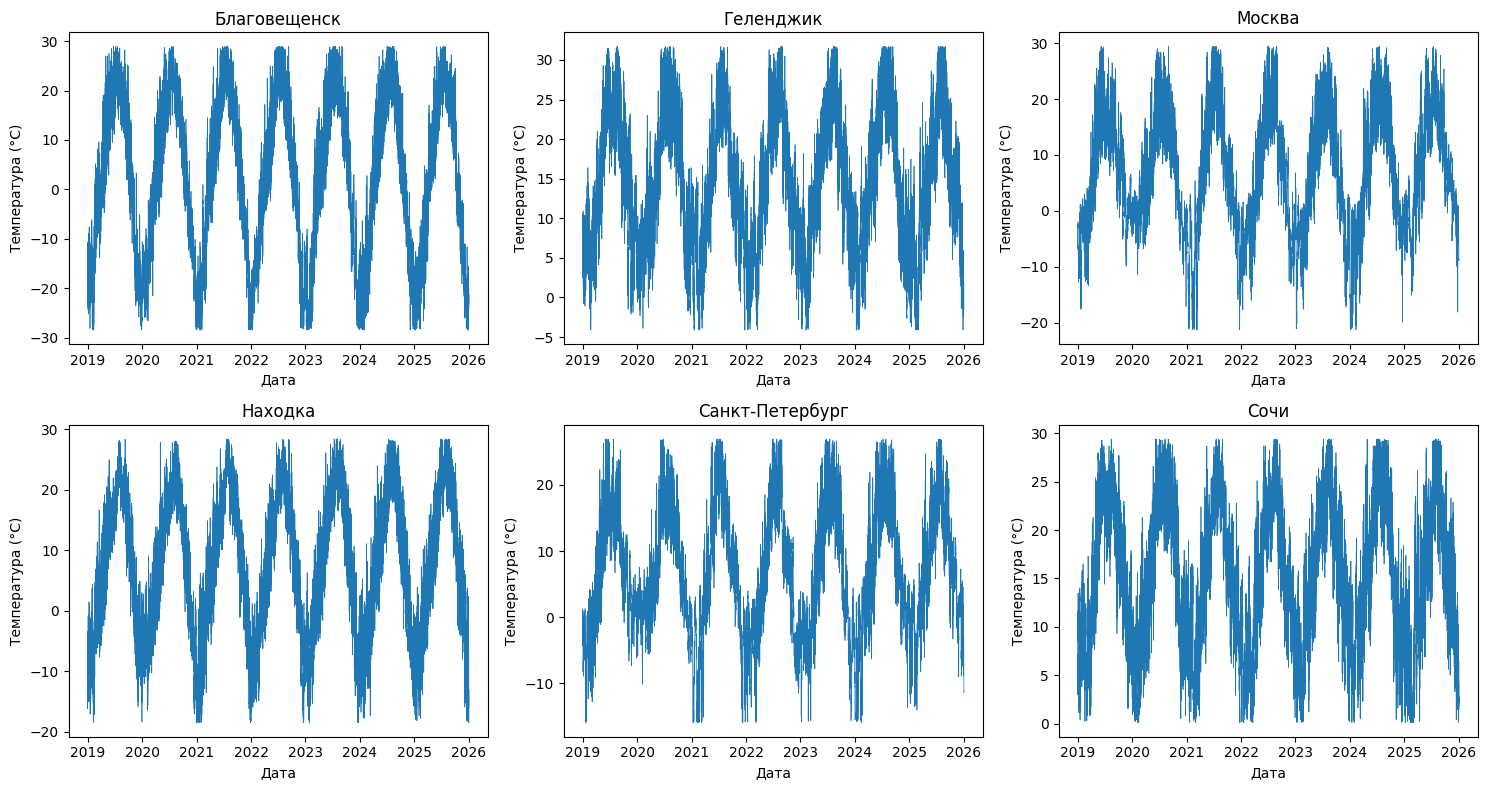

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, city in enumerate(data['city'].unique()):
    df_city = data[data['city'] == city].sort_values('ds')
    axes[i].plot(df_city['ds'], df_city['temperature_2m'], linewidth=0.5)
    axes[i].set_title(city)
    axes[i].set_xlabel('Дата')
    axes[i].set_ylabel('Температура (°C)')

plt.tight_layout()
plt.show()

Вывод: у всех городов хорошо видна годовая сезонность.
Благовещенск и Находка (Дальний Восток) имеют наибольший разброс температур.
Геленджик и Сочи (юг) — самые тёплые и с наименьшим перепадом.

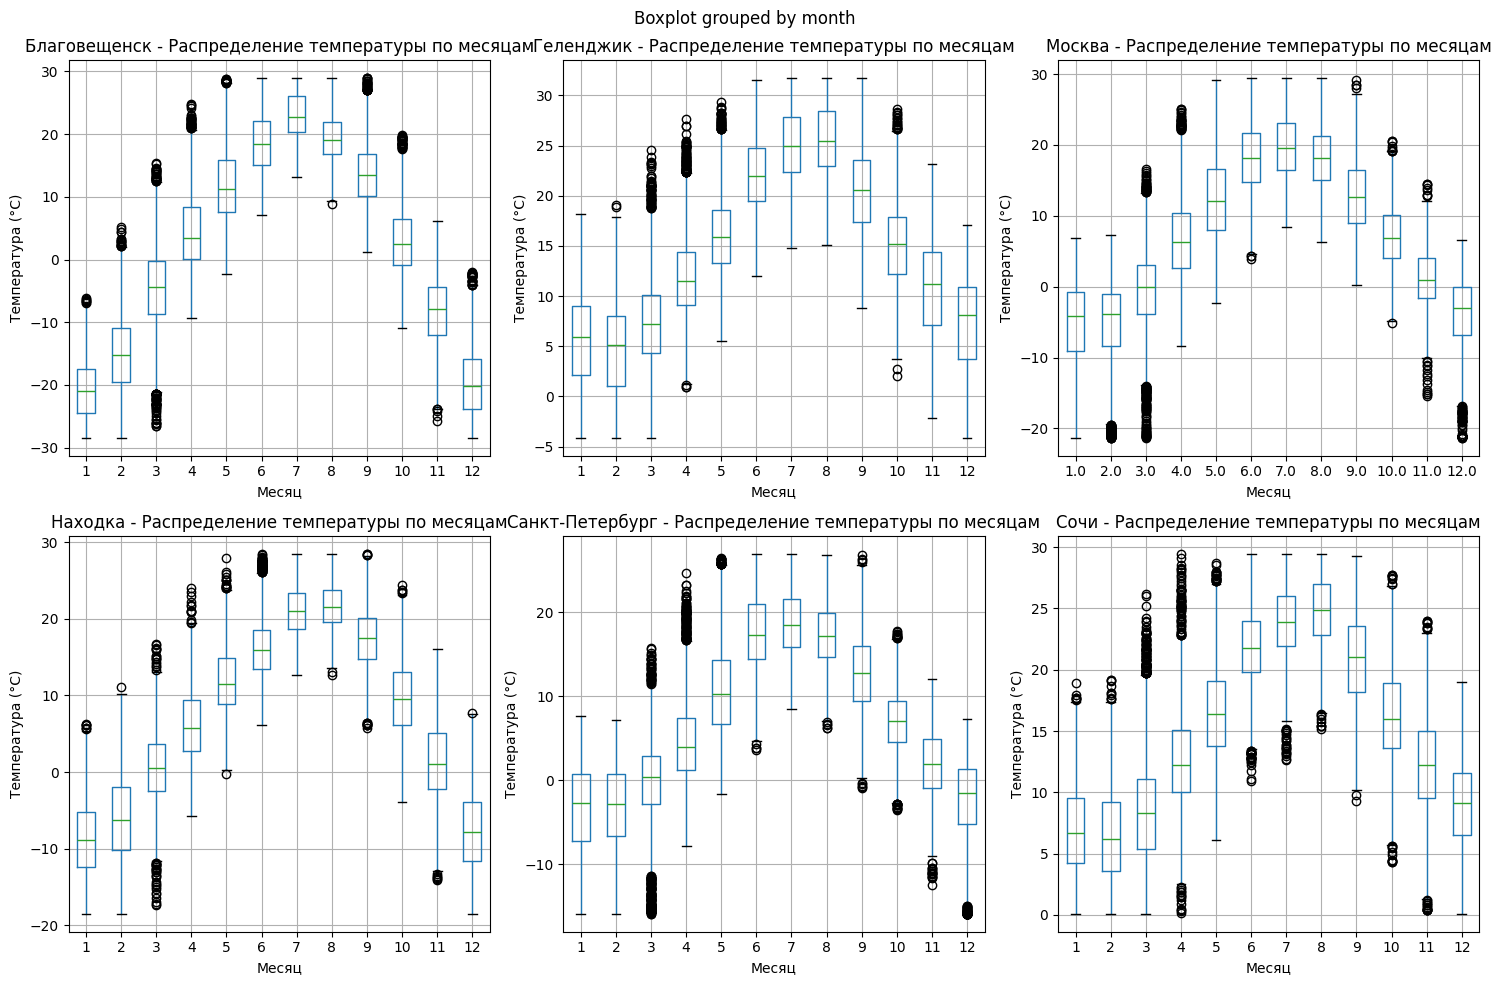

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, city in enumerate(data['city'].unique()):
    df_city = data[data['city'] == city].copy()
    df_city['month'] = df_city['ds'].dt.month

    df_city.boxplot(column='temperature_2m', by='month', ax=axes[idx])
    axes[idx].set_title(f'{city} - Распределение температуры по месяцам')
    axes[idx].set_xlabel('Месяц')
    axes[idx].set_ylabel('Температура (°C)')

plt.tight_layout()
plt.show()


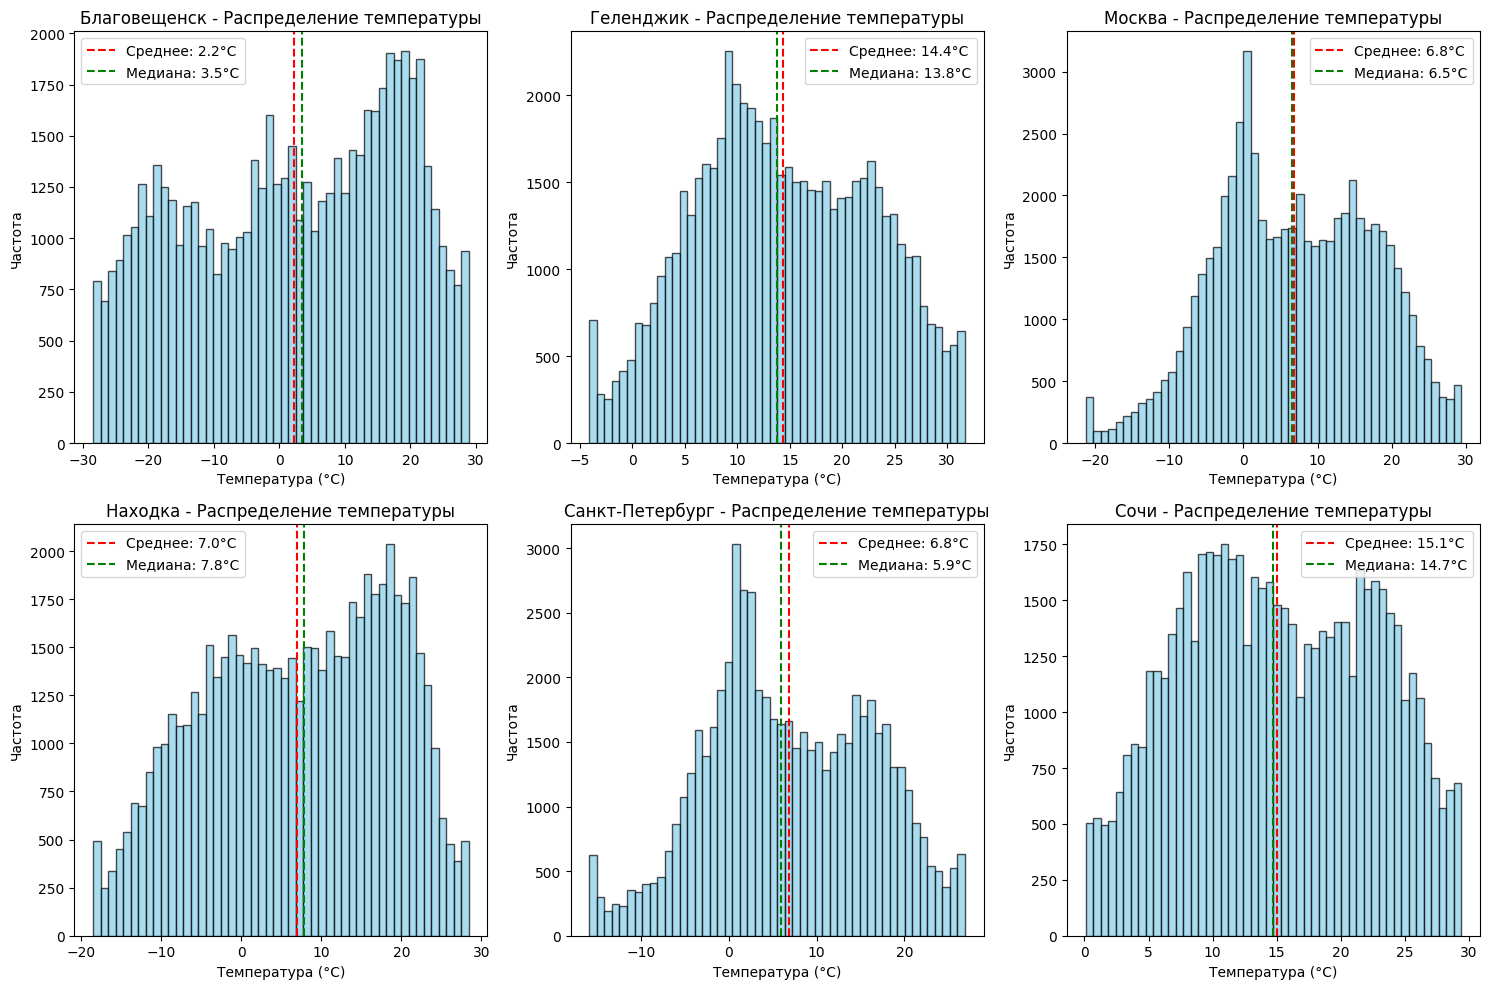

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, city in enumerate(data['city'].unique()):
    df_city = data[data['city'] == city]['temperature_2m'].dropna()
    
    axes[idx].hist(df_city, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].axvline(df_city.mean(), color='red', linestyle='--', label=f'Среднее: {df_city.mean():.1f}°C')
    axes[idx].axvline(df_city.median(), color='green', linestyle='--', label=f'Медиана: {df_city.median():.1f}°C')
    axes[idx].set_title(f'{city} - Распределение температуры')
    axes[idx].set_xlabel('Температура (°C)')
    axes[idx].set_ylabel('Частота')
    axes[idx].legend()

plt.tight_layout()
plt.show()

Среднее и медиана близки — нет сильной асимметрии.

### Проверка стационарности (ADF и KPSS тесты)

Стационарный ряд — это ряд, у которого среднее и дисперсия не меняются со временем.  
Это важно для временных рядов: нестационарный ряд сложнее прогнозировать.

In [40]:
from statsmodels.tsa.stattools import adfuller, kpss

print(f"{'Город':<22} {'ADF stat':>10} {'ADF p':>8} {'Стац.(ADF)':>11}  "
      f"{'KPSS stat':>10} {'KPSS p':>8} {'Стац.(KPSS)':>12}")
print('-' * 90)

for city in data['city'].unique():
    # Агрегируем до суточных средних — убирает шум суточного цикла
    daily = (data[data['city'] == city]
             .set_index('ds')['temperature_2m']
             .resample('D').mean()
             .dropna())

    adf_stat, adf_p, *_ = adfuller(daily, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(daily, regression='c', nlags='auto')

    adf_ok  = 'YES' if adf_p  < 0.05 else 'NO'
    kpss_ok = 'YES' if kpss_p > 0.05 else 'NO'
    print(f"{city:<22} {adf_stat:>10.3f} {adf_p:>8.4f} {adf_ok:>11}  "
          f"{kpss_stat:>10.3f} {kpss_p:>8.4f} {kpss_ok:>12}")

print()

Город                    ADF stat    ADF p  Стац.(ADF)   KPSS stat   KPSS p  Стац.(KPSS)
------------------------------------------------------------------------------------------
Благовещенск               -3.382   0.0116         YES       0.044   0.1000          YES
Геленджик                  -2.954   0.0395         YES       0.062   0.1000          YES
Москва                     -3.121   0.0251         YES       0.068   0.1000          YES
Находка                    -2.873   0.0485         YES       0.060   0.1000          YES
Санкт-Петербург            -3.089   0.0274         YES       0.067   0.1000          YES
Сочи                       -3.037   0.0315         YES       0.052   0.1000          YES



Тесты подтверждают стационарсть рядов 
### Декомпозиция временного ряда (тренд, сезонность, остатки)

Аддитивная декомпозиция разбивает ряд на три составляющие:
- **Тренд** — долгосрочное направление изменений
- **Сезонность** — повторяющийся годовой цикл (период = 365 дней)
- **Остатки** — всё что не объяснено трендом и сезонностью (шум, аномалии)

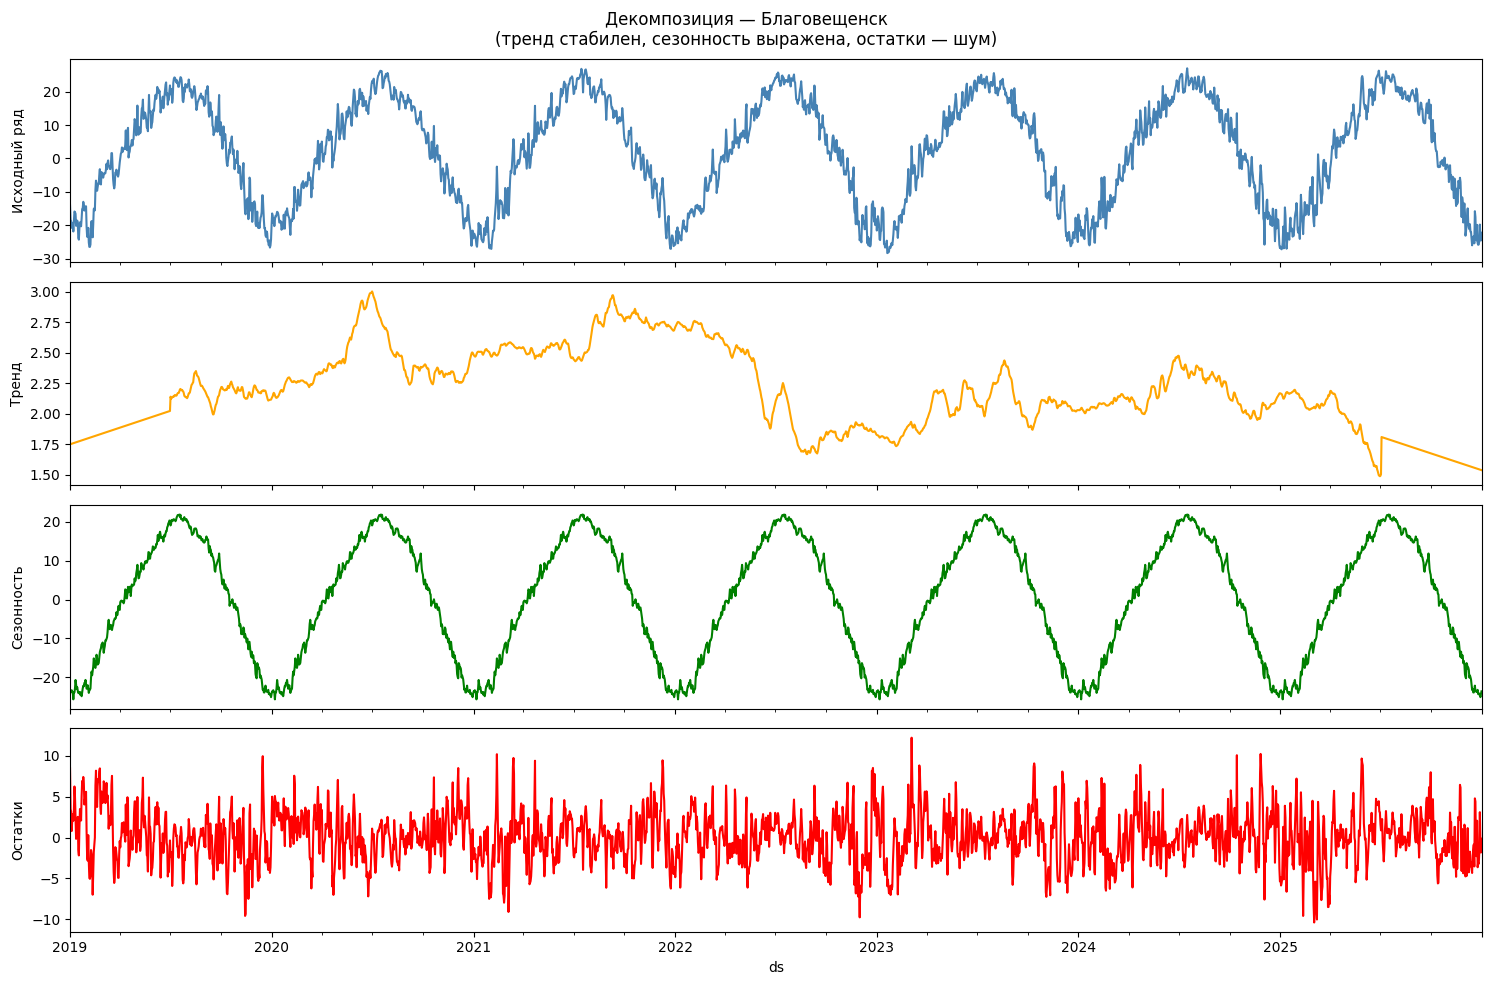

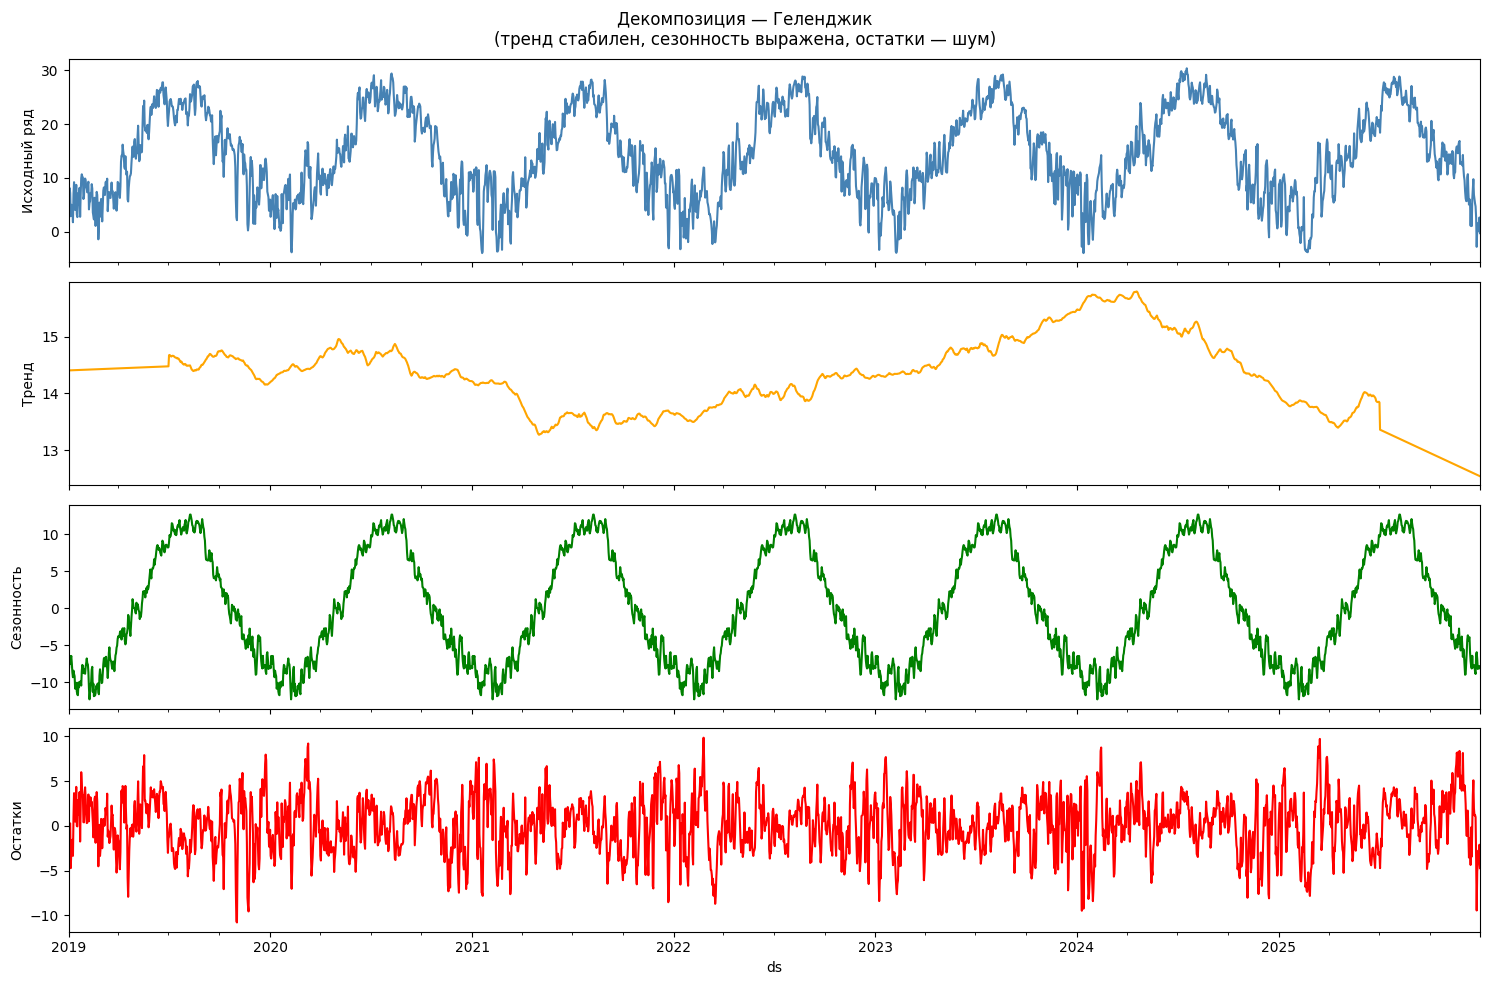

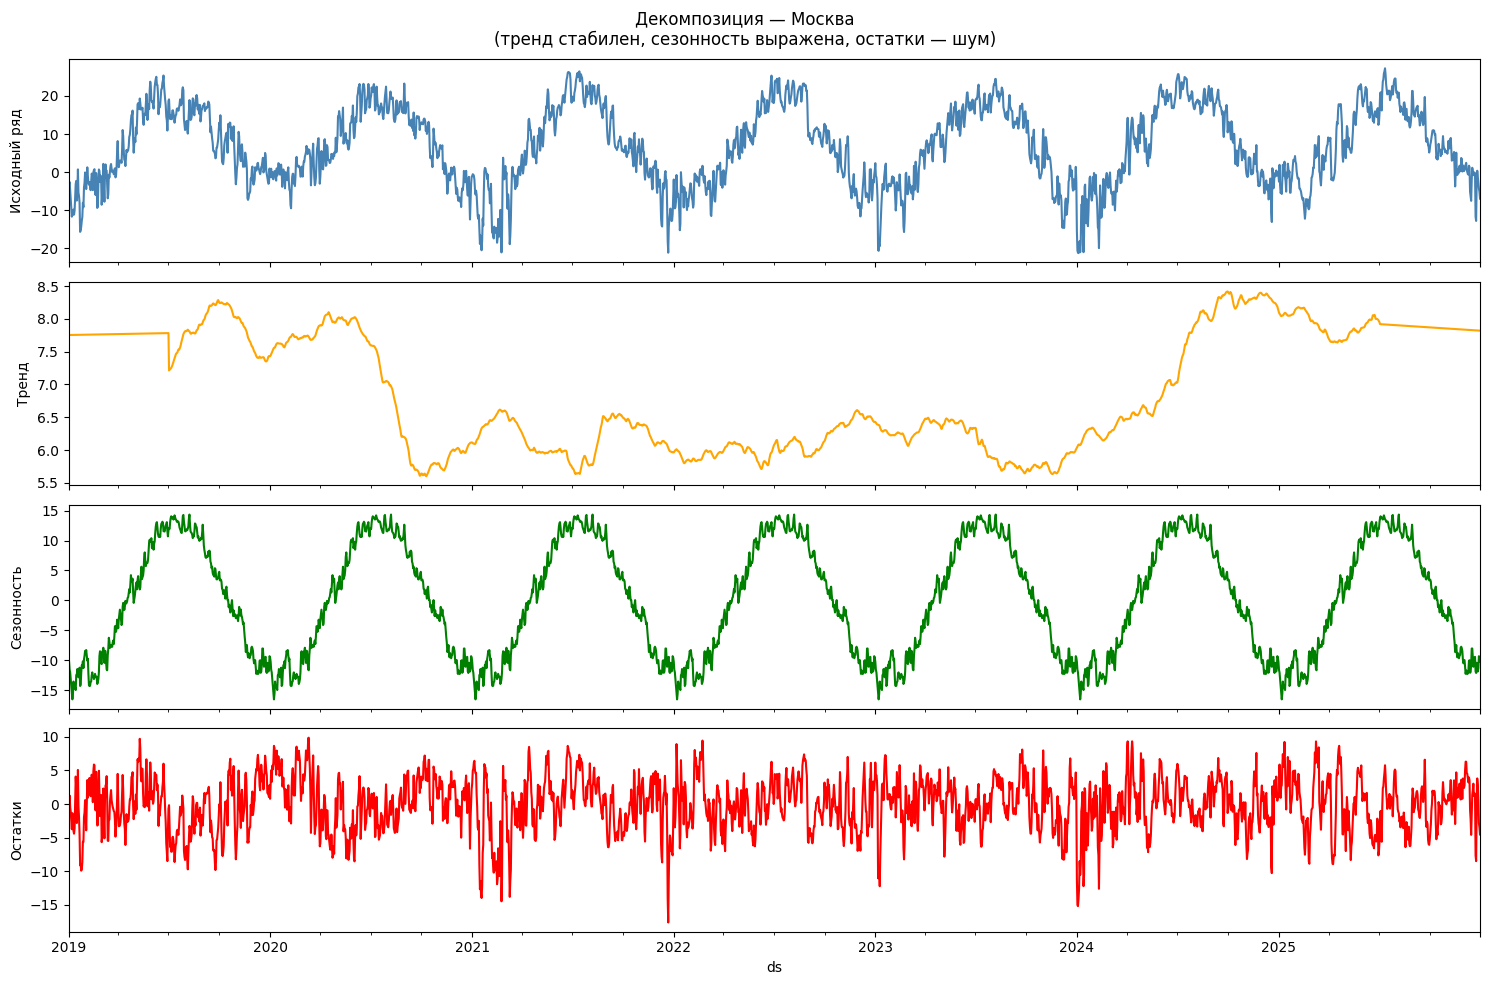

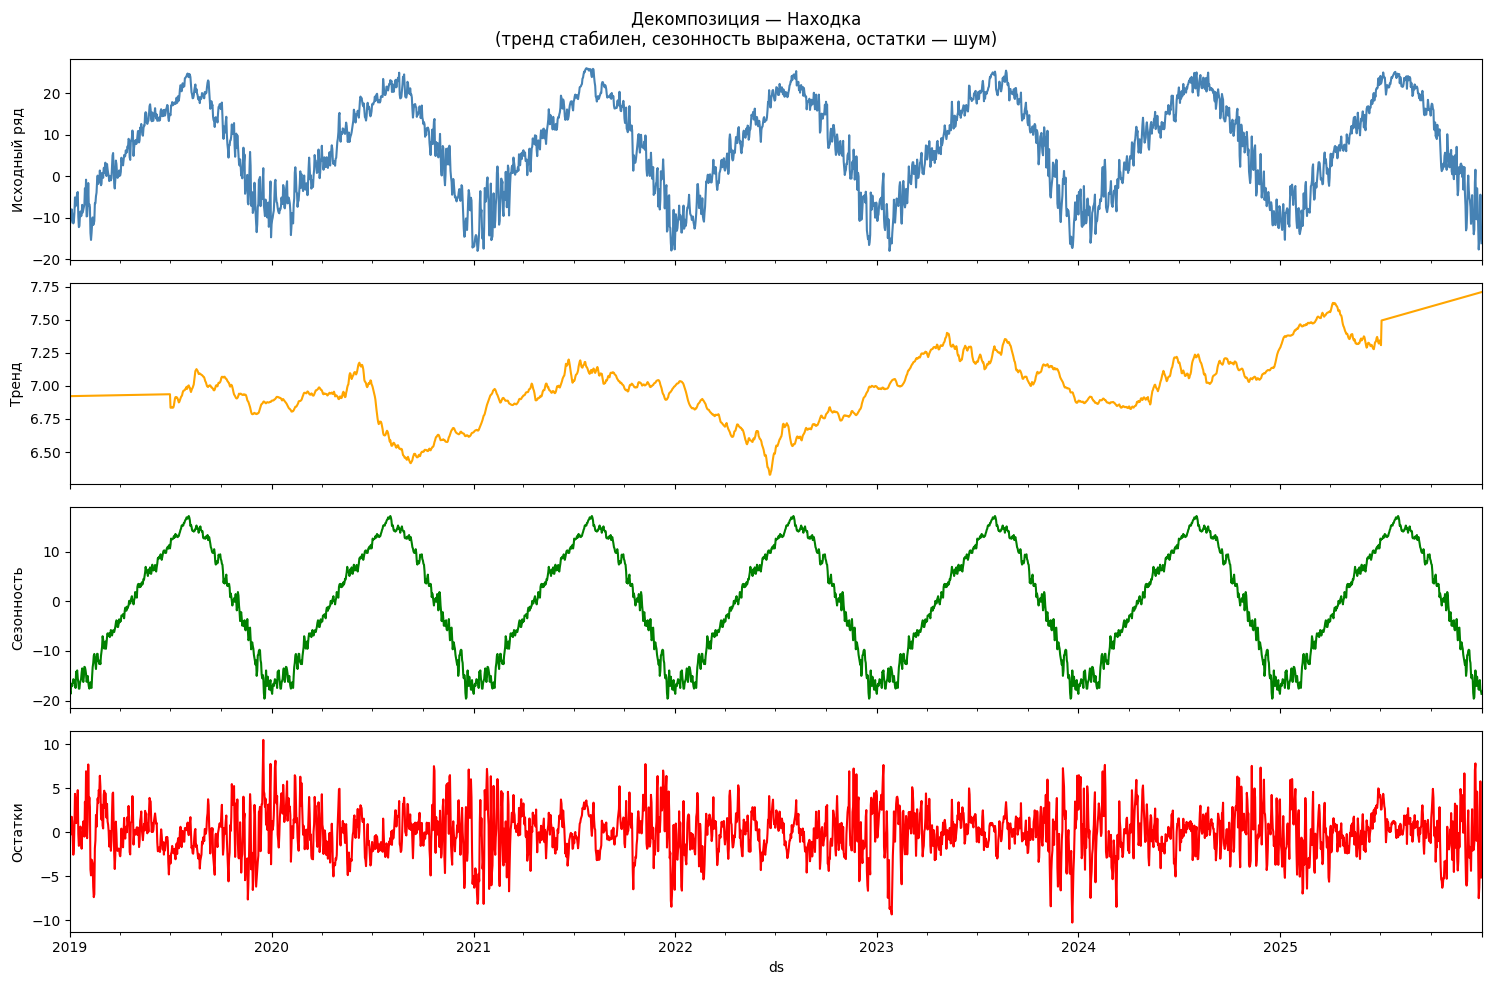

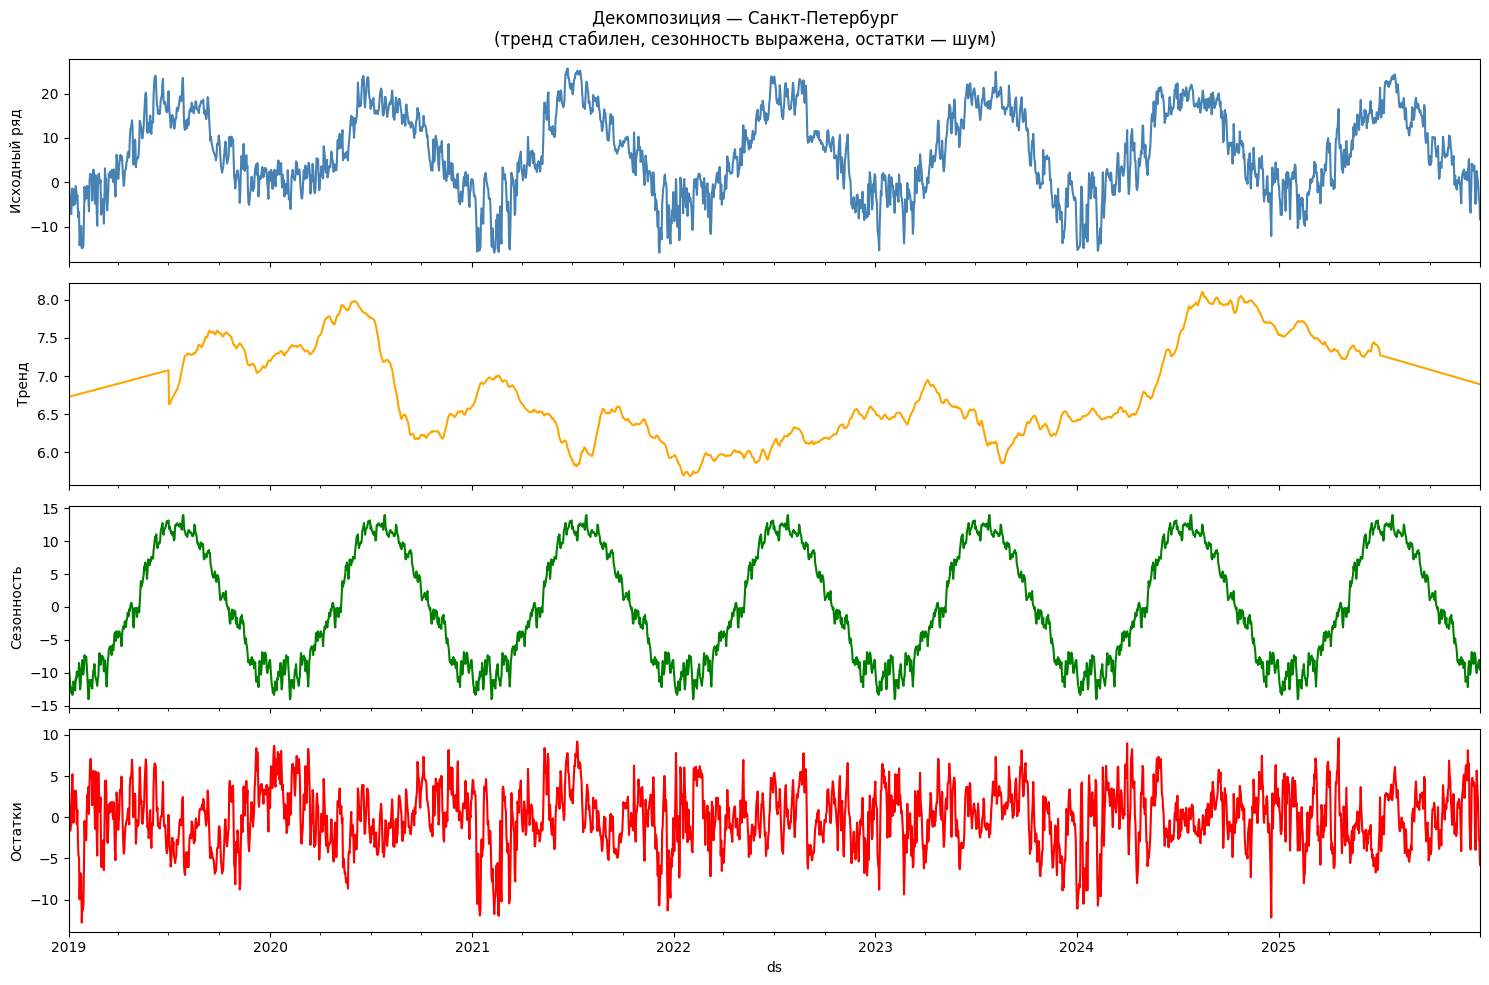

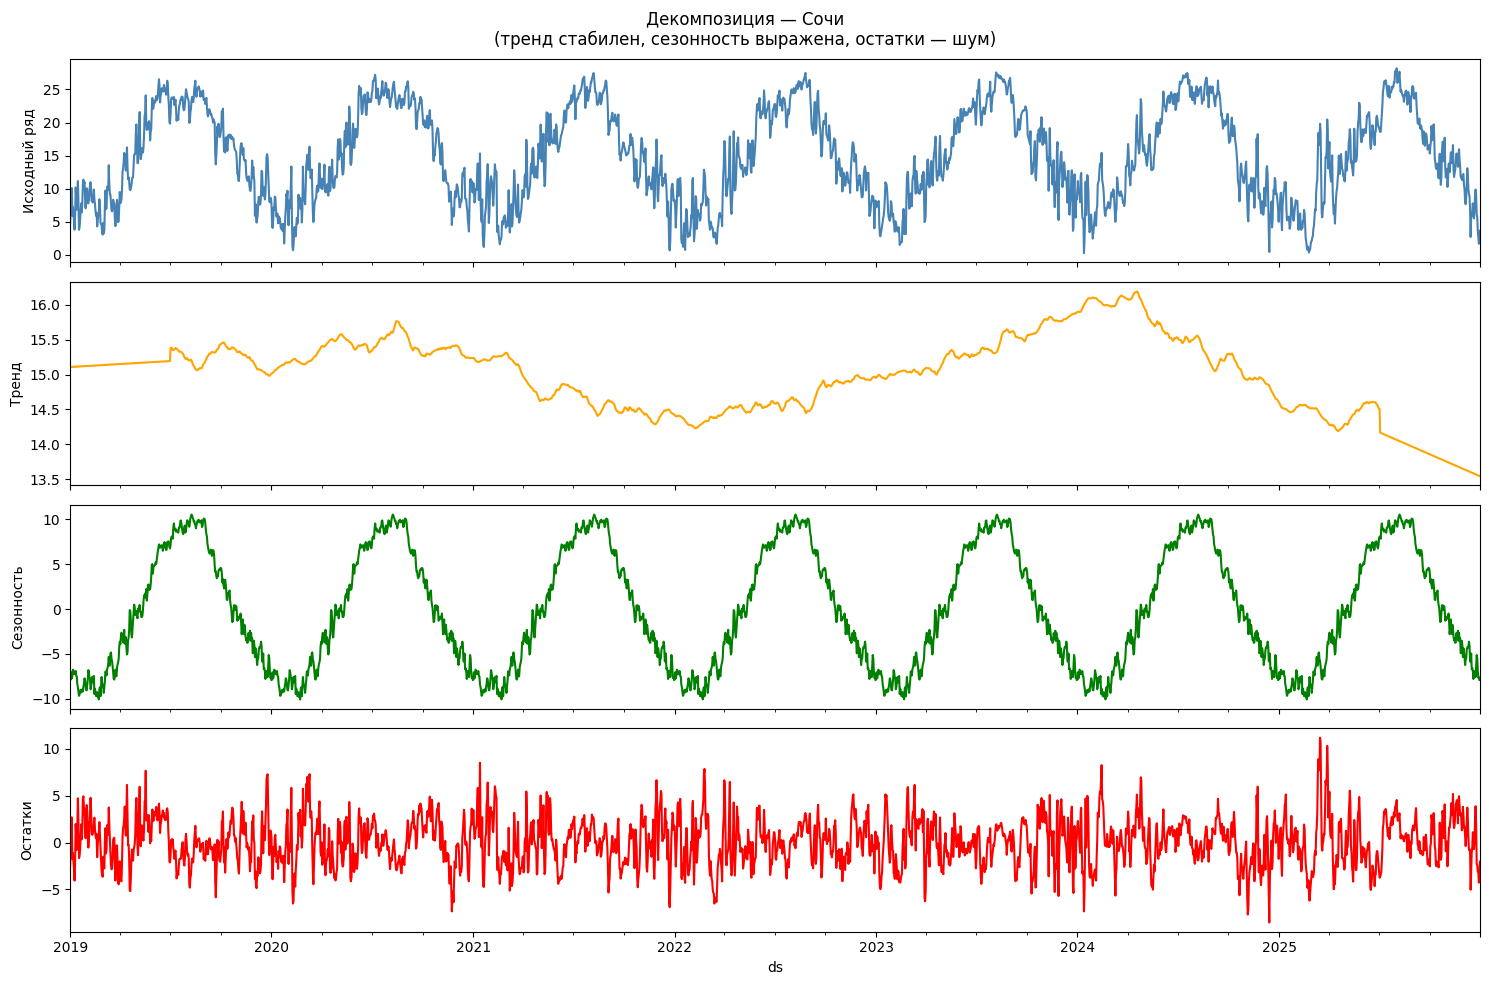

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

for city in data['city'].unique():
    daily = (data[data['city'] == city]
             .set_index('ds')['temperature_2m']
             .resample('D').mean()
             .dropna())

    decomp = seasonal_decompose(daily, model='additive', period=365, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
    decomp.observed.plot(ax=axes[0], color='steelblue')
    axes[0].set_ylabel('Исходный ряд')

    decomp.trend.plot(ax=axes[1], color='orange')
    axes[1].set_ylabel('Тренд')

    decomp.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_ylabel('Сезонность')

    decomp.resid.plot(ax=axes[3], color='red')
    axes[3].set_ylabel('Остатки')

    plt.suptitle(f'Декомпозиция — {city}\n'
                 f'(тренд стабилен, сезонность выражена, остатки — шум)', fontsize=12)
    plt.tight_layout()
    plt.show()

### Спектральный анализ (БПФ — Быстрое Преобразование Фурье)

БПФ показывает на каких периодах сосредоточена основная энергия колебаний ряда.  
Высокая амплитуда на каком-то периоде = ряд заметно колеблется с такой частотой.
Ожидаемые пики  1 день, 182 дня, 365 дней. (сутки полгода год )

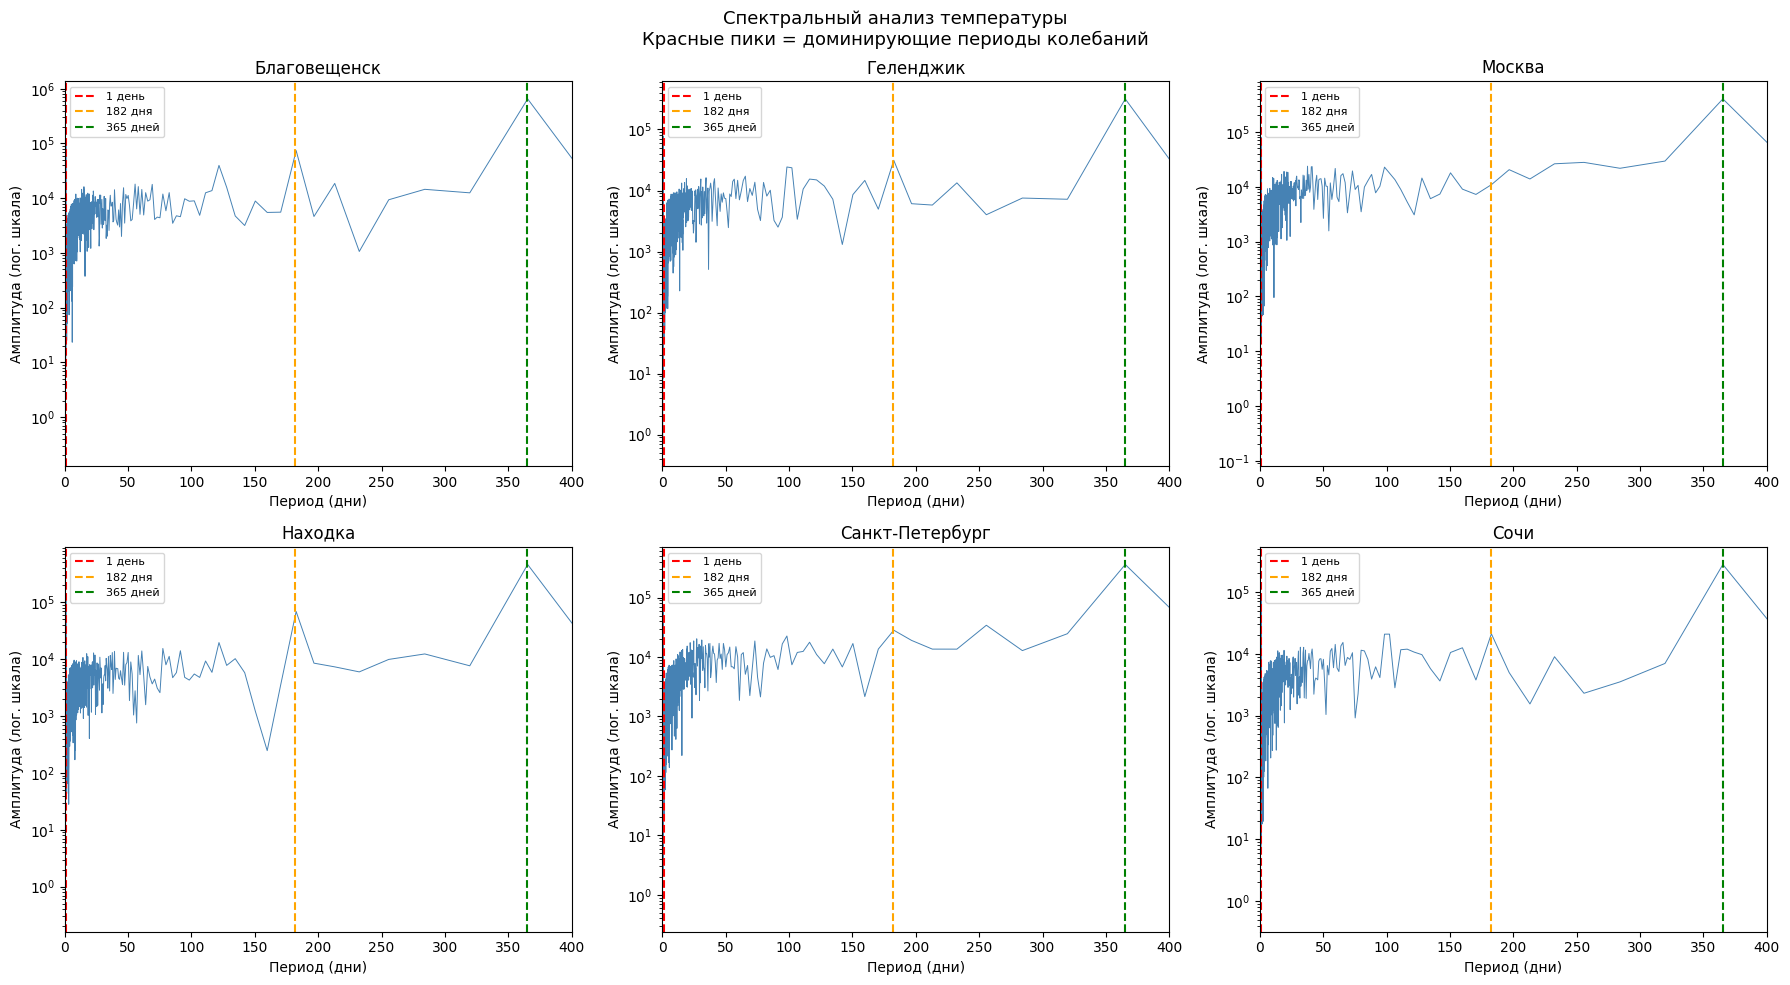

In [42]:
from scipy.fft import fft, fftfreq

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, city in enumerate(data['city'].unique()):
    hourly = (data[data['city'] == city]
              .set_index('ds')['temperature_2m']
              .resample('h').mean()
              .interpolate())

    N  = len(hourly)
    yf = np.abs(fft(hourly.values - hourly.mean()))[:N // 2]
    xf = fftfreq(N, d=1.0)[:N // 2]
    periods_days = 1.0 / (xf[1:] * 24 + 1e-12)

    axes[i].semilogy(periods_days, yf[1:], lw=0.7, color='steelblue')
    axes[i].set_xlim(0, 400)
    axes[i].set_xlabel('Период (дни)')
    axes[i].set_ylabel('Амплитуда (лог. шкала)')
    axes[i].set_title(city)

    for label, p, color in [('1 день', 1, 'red'), ('182 дня', 182, 'orange'), ('365 дней', 365, 'green')]:
        axes[i].axvline(p, color=color, lw=1.5, ls='--', label=label)
    axes[i].legend(fontsize=8)

plt.suptitle('Спектральный анализ температуры\n'
             'Красные пики = доминирующие периоды колебаний', fontsize=13)
plt.tight_layout()
plt.show()


Вывод: у всех городов чётко видны пики . Это подтверждает что суточный и годовой циклы — главные источники вариации.Поэтому в признаках используем sin/cos кодирование часа и дня года.

## Feature Engineering

Строим признаки из скользящего окна 168 часов (7 дней) для прогноза температуры  
на горизонты 24, 48, 72, 96, 120, 144, 168 часов.

In [43]:
WINDOW   = 7 * 24
HORIZONS = list(range(24, 169, 24)) 
def make_features(df, window=WINDOW):
    city2id = {c: i for i, c in enumerate(sorted(df['city'].unique()))}
    records = []
    for city, grp in df.groupby('city'):
        grp = grp.sort_values('ds').reset_index(drop=True)
        T = grp['temperature_2m'].values
        HUM = grp['relative_humidity_2m'].values if 'relative_humidity_2m' in grp.columns else np.zeros(len(grp))
        PRESS  = grp['surface_pressure'].values if 'surface_pressure' in grp.columns else np.zeros(len(grp))
        WIND = grp['wind_speed_10m'].values if 'wind_speed_10m' in grp.columns else np.zeros(len(grp))
        TS = grp['ds'].values
        for i in range(window, len(T) - max(HORIZONS)):
            w = T[i - window: i]
            w24 = T[i - 24: i]
            ts = pd.Timestamp(TS[i])
            row = {
                # Лаги температуры
                'lag_1h': T[i - 1],
                'lag_2h': T[i - 2],
                'lag_3h': T[i - 3],
                'lag_6h': T[i - 6],
                'lag_12h': T[i - 12],
                'lag_24h': T[i - 24],
                'lag_48h': T[i - 48],
                'lag_72h': T[i - 72],
                'lag_96h': T[i - 96],
                'lag_120h':T[i - 120],
                'lag_144h': T[i - 144],
                'lag_168h':T[i - 168],
                'roll_mean_24h': w24.mean(),
                'roll_std_24h': w24.std(),
                'roll_mean_7d':w.mean(),
                'roll_std_7d': w.std(),
                'roll_min_7d': w.min(),
                'roll_max_7d':w.max(),
                'diff_1h': T[i - 1] - T[i - 2],
                'diff_24h': T[i - 1] - T[i - 25] if i >= 25 else 0.0,
                'humidity':HUM[i - 1],
                'pressure': PRESS[i - 1],
                'wind': WIND[i - 1],
                'hour': ts.hour,
                'dayofweek': ts.dayofweek,
                'month': ts.month,
                'dayofyear': ts.dayofyear,
                # кодируем прихнаки через синусы и косинусы 
                'sin_hour': np.sin(2 * np.pi * ts.hour / 24),
                'cos_hour':np.cos(2 * np.pi * ts.hour / 24),
                'sin_doy':np.sin(2 * np.pi * ts.dayofyear / 365.25),
                'cos_doy': np.cos(2 * np.pi * ts.dayofyear / 365.25),
                'city_id':   city2id[city],
                '_ds': TS[i],
                '_city': city,
            }
            for h in HORIZONS:
                row[f'target_{h}h'] = T[i + h - 1]
            records.append(row)
    return pd.DataFrame(records)
feat_df = make_features(data)
FEATURE_COLS = [c for c in feat_df.columns
                if not c.startswith('target_') and not c.startswith('_')]
print(f"Признаков: {len(FEATURE_COLS)}: {FEATURE_COLS}")

Признаков: 32: ['lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_72h', 'lag_96h', 'lag_120h', 'lag_144h', 'lag_168h', 'roll_mean_24h', 'roll_std_24h', 'roll_mean_7d', 'roll_std_7d', 'roll_min_7d', 'roll_max_7d', 'diff_1h', 'diff_24h', 'humidity', 'pressure', 'wind', 'hour', 'dayofweek', 'month', 'dayofyear', 'sin_hour', 'cos_hour', 'sin_doy', 'cos_doy', 'city_id']


## Хронологическое разделение Train / Val / Test

In [44]:
feat_df['_ds'] = pd.to_datetime(feat_df['_ds'])

train_df = feat_df[feat_df['_ds'] < '2024-01-01'].copy()
val_df   = feat_df[(feat_df['_ds'] >= '2024-01-01') & (feat_df['_ds'] < '2024-10-01')].copy()
test_df  = feat_df[feat_df['_ds'] >= '2024-10-01'].copy()

X_train = train_df[FEATURE_COLS].values.astype(np.float32)
X_val   = val_df[FEATURE_COLS].values.astype(np.float32)
X_test  = test_df[FEATURE_COLS].values.astype(np.float32)

print(f"Train:{X_train.shape[0]:>7,} строк  ({train_df['_ds'].min().date()} – {train_df['_ds'].max().date()})")
print(f"Val:{X_val.shape[0]:>7,} строк  ({val_df['_ds'].min().date()} – {val_df['_ds'].max().date()})")
print(f"Test: {X_test.shape[0]:>7,} строк  ({test_df['_ds'].min().date()} – {test_df['_ds'].max().date()})")

Train:261,902 строк  (2019-01-08 – 2023-12-31)
Val: 39,456 строк  (2024-01-01 – 2024-09-30)
Test:  64,800 строк  (2024-10-01 – 2025-12-25)


## Метрики качества прогноза
Для оценки качества используем 5 метрик
- **MAE**  mean(\|y - ŷ\|)  Средняя ошибка в градусах.
- **WAPE** sum(\|y - ŷ\|) / sum(\|y\|)  Взвешенная процентная ошибка.
- **MAPE** mean(\|y - ŷ\| / \|y\|) Средняя процентная ошибка.
- **Directional Accuracy** mean(sign(y-y_last) == sign(ŷ-y_last)) Доля правильно угаданных направлений
- **Directional R²**  R² на направлениях изменений Насколько хорошо предсказываем величину изменения


In [45]:
from sklearn.metrics import mean_absolute_error

def wape(y_true, y_pred):
    """
    Weighted Absolute Percentage Error.
    Сумма абсолютных ошибок делённая на сумму абсолютных значений таргета.
    Устойчива к нулям в отличие от MAPE.
    """
    return np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-9)

def mape(y_true, y_pred):
    """
    Mean Absolute Percentage Error.
    Исключаем точки где |y| < 0.1 чтобы не делить на ноль
    (температура может быть близка к 0°C).
    """
    mask = np.abs(y_true) > 0.1
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def directional_accuracy(y_true, y_pred, y_last):
    """
    Доля случаев где модель правильно угадала направление изменения:
    будет теплее или холоднее чем сейчас (y_last).
    0.5 = случайное угадывание, 1.0 = идеально.
    """
    return np.mean(np.sign(y_true - y_last) == np.sign(y_pred - y_last))

def directional_r2(y_true, y_pred, y_last):
    """
    R² применённый к изменениям (y - y_last) вместо абсолютных значений.
    Показывает насколько хорошо модель предсказывает величину изменения температуры.
    """
    td    = y_true - y_last   # фактическое изменение
    pd_   = y_pred - y_last   # предсказанное изменение
    ss_res = ((td - pd_) ** 2).sum()
    ss_tot = ((td - td.mean()) ** 2).sum()
    return 1 - ss_res / (ss_tot + 1e-9)

def get_metrics(y_true, y_pred, y_last):
    """Считает все 5 метрик и возвращает словарь."""
    return {
        'MAE':     round(mean_absolute_error(y_true, y_pred), 4),
        'WAPE':    round(wape(y_true, y_pred), 4),
        'MAPE':    round(mape(y_true, y_pred), 4),
        'Dir.Acc': round(directional_accuracy(y_true, y_pred, y_last), 4),
        'Dir.R2':  round(directional_r2(y_true, y_pred, y_last), 4),
    }

print("Метрики определены: MAE, WAPE, MAPE, Directional Accuracy, Directional R²")

Метрики определены: MAE, WAPE, MAPE, Directional Accuracy, Directional R²


## Обучение моделей
### Direct-стратегия (отдельная модель на каждый горизонт)

In [46]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
direct_results  = {}
best_lgb_models = {}
best_lgb_preds  = {}
for h in HORIZONS:
    target = f'target_{h}h'
    y_train = train_df[target].values.astype(np.float32)
    y_val = val_df[target].values.astype(np.float32)
    y_test = test_df[target].values.astype(np.float32)
    y_last = test_df['lag_1h'].values.astype(np.float32)
    direct_results[h] = {}
    print(f"\n── Горизонт {h}h ({h//24} дней) ──")
    # Decision Tree
    dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)
    dt.fit(X_train, y_train)
    p_dt = dt.predict(X_test)
    direct_results[h]['DecisionTree'] = get_metrics(y_test, p_dt, y_last)
    print(f"  DT:  MAE={direct_results[h]['DecisionTree']['MAE']:.3f}")
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=14, min_samples_leaf=10,
                                n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    p_rf = rf.predict(X_test)
    direct_results[h]['RandomForest'] = get_metrics(y_test, p_rf, y_last)
    print(f"  RF:  MAE={direct_results[h]['RandomForest']['MAE']:.3f}")
    def objective(trial):
        params = dict(
            n_estimators= trial.suggest_int('n_estimators', 200, 800),
            num_leaves = trial.suggest_int('num_leaves', 31, 200),
            learning_rate = trial.suggest_float('lr', 0.01, 0.2, log=True),
            max_depth = trial.suggest_int('max_depth', 4, 12),
            min_child_samples = trial.suggest_int('min_child_samples', 10, 60),
            subsample = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
            reg_alpha = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            random_state=42, n_jobs=-1, verbose=-1,
        )
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)])
        return mean_absolute_error(y_val, m.predict(X_val))
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=30, show_progress_bar=False)
    best_params = {k: v for k, v in study.best_params.items() if k != 'lr'}
    best_params['learning_rate'] = study.best_params['lr']
    best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})
    lgb_model = lgb.LGBMRegressor(**best_params)
    lgb_model.fit(X_train, y_train)
    p_lgb = lgb_model.predict(X_test)
    direct_results[h]['LightGBM'] = get_metrics(y_test, p_lgb, y_last)
    best_lgb_models[h] = lgb_model
    best_lgb_preds[h]  = p_lgb
    print(f"  LGB: MAE={direct_results[h]['LightGBM']['MAE']:.3f}  (val_MAE={study.best_value:.3f})")

print("\nDirect-стратегия обучена")


── Горизонт 24h (1 дней) ──
  DT:  MAE=2.350
  RF:  MAE=2.196
  LGB: MAE=2.100  (val_MAE=2.063)

── Горизонт 48h (2 дней) ──
  DT:  MAE=3.009
  RF:  MAE=2.802
  LGB: MAE=2.671  (val_MAE=2.546)

── Горизонт 72h (3 дней) ──
  DT:  MAE=3.355
  RF:  MAE=3.086
  LGB: MAE=2.974  (val_MAE=2.724)

── Горизонт 96h (4 дней) ──
  DT:  MAE=3.460
  RF:  MAE=3.204
  LGB: MAE=3.028  (val_MAE=2.788)

── Горизонт 120h (5 дней) ──
  DT:  MAE=3.626
  RF:  MAE=3.340
  LGB: MAE=3.144  (val_MAE=2.812)

── Горизонт 144h (6 дней) ──
  DT:  MAE=3.593
  RF:  MAE=3.415
  LGB: MAE=3.219  (val_MAE=2.835)

── Горизонт 168h (7 дней) ──
  DT:  MAE=3.693
  RF:  MAE=3.482
  LGB: MAE=3.268  (val_MAE=2.855)

Direct-стратегия обучена


Анализируя метрики можно понять что бустинг является лучший вариантом показывает лучший результат среди 3 методов. 

In [47]:

y_train_24 = train_df['target_24h'].values.astype(np.float32)
y_val_24   = val_df['target_24h'].values.astype(np.float32)

def rec_objective(trial):
    params = dict(
        n_estimators= trial.suggest_int('n_estimators', 200, 600),
        num_leaves= trial.suggest_int('num_leaves', 31, 150),
        learning_rate = trial.suggest_float('lr', 0.01, 0.2, log=True),
        max_depth = trial.suggest_int('max_depth', 4, 10),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 50),
        subsample = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        random_state=42, n_jobs=-1, verbose=-1,
    )
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train, y_train_24,
          eval_set=[(X_val, y_val_24)],
          callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)])
    return mean_absolute_error(y_val_24, m.predict(X_val))
study_rec = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rec.optimize(rec_objective, n_trials=25, show_progress_bar=False)
rec_params = {k: v for k, v in study_rec.best_params.items() if k != 'lr'}
rec_params['learning_rate'] = study_rec.best_params['lr']
rec_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})
rec_model = lgb.LGBMRegressor(**rec_params)
rec_model.fit(X_train, y_train_24)
print(f"Рекурсивная модель обучена. Val MAE (24h): {study_rec.best_value:.3f} °C")

Рекурсивная модель обучена. Val MAE (24h): 2.064 °C


 Ошибка 2.064 означает, что модель ошибается в среднем на 2.064 градуса Цельсия. Что является хорошим результатом прогнозирования емпературы. 

In [48]:
# Индексы lag-признаков для сдвига при рекурсии
lag_names   = ['lag_1h','lag_2h','lag_3h','lag_6h','lag_12h',
               'lag_24h','lag_48h','lag_72h','lag_96h','lag_120h','lag_144h','lag_168h']
lag_indices = [FEATURE_COLS.index(c) for c in lag_names if c in FEATURE_COLS]
def recursive_predict(model, X_start, n_steps=7):
    X_cur = X_start.copy().astype(np.float64)
    all_preds = []
    for _ in range(n_steps):
        pred = model.predict(X_cur)
        all_preds.append(pred.copy())
        # Сдвигаем лаги: lag_2 ← lag_1, ..., lag_1 ← pred
        for k in range(len(lag_indices) - 1, 0, -1):
            X_cur[:, lag_indices[k]] = X_cur[:, lag_indices[k - 1]]
        X_cur[:, lag_indices[0]] = pred
    return np.stack(all_preds, axis=1)
rec_preds_matrix = recursive_predict(rec_model, X_test, n_steps=7)
recursive_results = {}
for step_i, h in enumerate(HORIZONS):
    y_test_h = test_df[f'target_{h}h'].values.astype(np.float32)
    y_last   = test_df['lag_1h'].values.astype(np.float32)
    recursive_results[h] = get_metrics(y_test_h, rec_preds_matrix[:, step_i], y_last)
print(f"{'Горизонт':>10} {'MAE':>8} {'Dir.Acc':>9}")
for h in HORIZONS:
    m = recursive_results[h]
    print(f"{h:>8}h   {m['MAE']:>8.3f} {m['Dir.Acc']:>9.3f}")

  Горизонт      MAE   Dir.Acc
      24h      2.091     0.625
      48h      2.632     0.653
      72h      2.919     0.658
      96h      3.121     0.659
     120h      3.258     0.669
     144h      3.386     0.673
     168h      3.522     0.667


 Она держится в диапазоне 62.5% — 67.3%. Это означает, что в 2 случаях из 3 модель правильно прогнозирует, пойдет ли температура вверх или вниз относительно предыдущего момента времени.

## Сравнение стратегий

Собираем все результаты в одну таблицу и смотрим:
- Какая модель лучше на каждом горизонте?
- Как Direct и Recursive стратегии соотносятся друг с другом?

**Direct** — для каждого горизонта своя отдельная модель.  
**Recursive** — одна модель на 24h, применяется итерационно.

In [49]:
rows = []
for h in HORIZONS:
    for model_name, metrics in direct_results[h].items():
        rows.append({'Горизонт (ч)': h, 'Стратегия': 'Direct', 'Модель': model_name, **metrics})
    rows.append({'Горизонт (ч)': h, 'Стратегия': 'Recursive', 'Модель': 'LightGBM',
                 **recursive_results[h]})

results_df = pd.DataFrame(rows)
results_df.sort_values(['Горизонт (ч)', 'MAE']).reset_index(drop=True)

,Горизонт (ч),Стратегия,Модель,MAE,WAPE,MAPE,Dir.Acc,Dir.R2
0,24,Recursive,LightGBM,2.0908,0.1821,0.5976,0.6251,0.2127
1,24,Direct,LightGBM,2.1003,0.1829,0.6030,0.6231,0.2079
2,24,Direct,RandomForest,2.1965,0.1913,0.6431,0.6011,0.1313
3,24,Direct,DecisionTree,2.3499,0.2046,0.6886,0.5652,-0.0034
4,48,Recursive,LightGBM,2.6321,0.2293,0.7698,0.6532,0.2704
5,48,Direct,LightGBM,2.6709,0.2327,0.7860,0.6494,0.2534
6,48,Direct,RandomForest,2.8018,0.2441,0.8434,0.6303,0.1800
7,48,Direct,DecisionTree,3.0092,0.2622,0.9126,0.6026,0.0500
8,72,Recursive,LightGBM,2.9192,0.2546,0.8787,0.6577,0.2522
9,72,Direct,LightGBM,2.9740,0.2594,0.8958,0.6600,0.2342


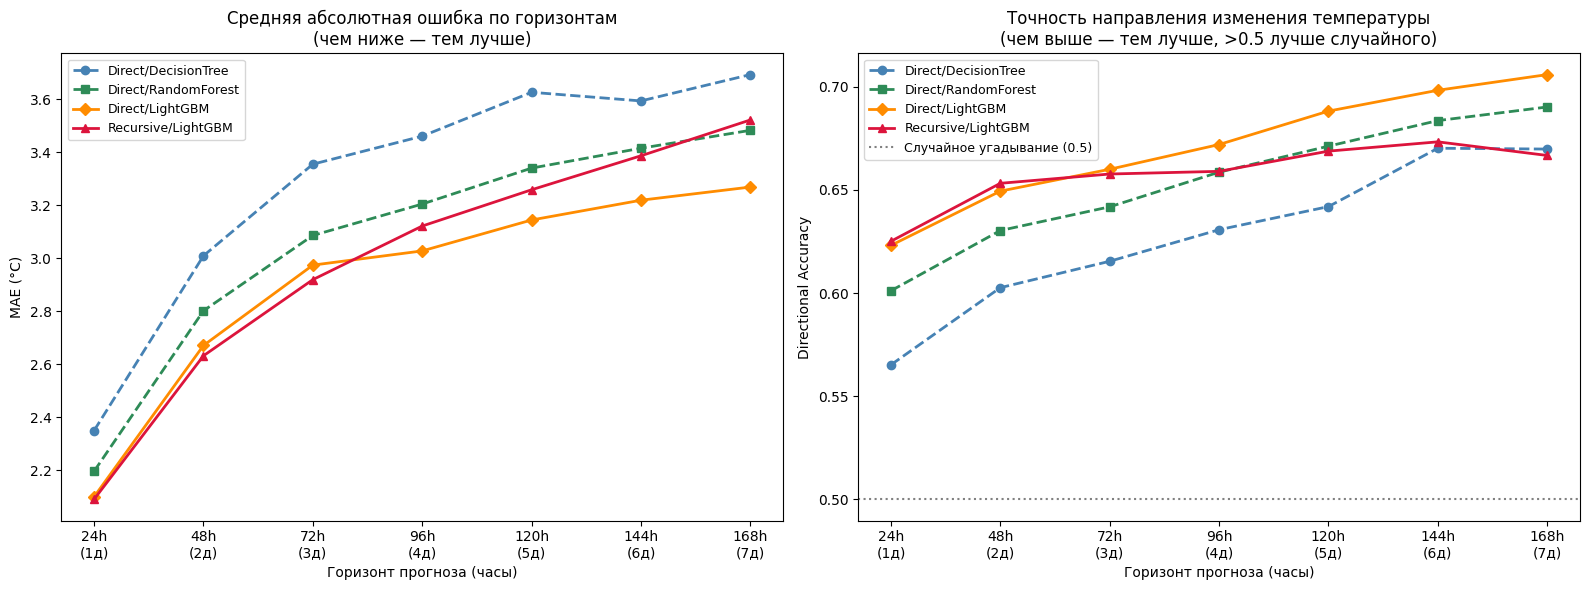

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = {
    ('Direct',    'DecisionTree'): ('steelblue',  '--', 'o'),
    ('Direct',    'RandomForest'): ('seagreen',   '--', 's'),
    ('Direct',    'LightGBM'):     ('darkorange', '-',  'D'),
    ('Recursive', 'LightGBM'):     ('crimson',    '-',  '^'),
}
for (strategy, model), (color, ls, marker) in palette.items():
    sub = results_df[(results_df['Стратегия'] == strategy) & (results_df['Модель'] == model)]
    if sub.empty:
        continue
    axes[0].plot(sub['Горизонт (ч)'], sub['MAE'],
                 color=color, ls=ls, marker=marker, lw=2, label=f'{strategy}/{model}')
    axes[1].plot(sub['Горизонт (ч)'], sub['Dir.Acc'],
                 color=color, ls=ls, marker=marker, lw=2, label=f'{strategy}/{model}')

# Левый график: MAE
axes[0].set_xlabel('Горизонт прогноза (часы)')
axes[0].set_ylabel('MAE (°C)')
axes[0].set_title('Средняя абсолютная ошибка по горизонтам\n(чем ниже — тем лучше)')
axes[0].set_xticks(HORIZONS)
axes[0].set_xticklabels([f'{h}h\n({h//24}д)' for h in HORIZONS])
axes[0].legend(fontsize=9)

# Правый график: Directional Accuracy
axes[1].axhline(0.5, color='gray', ls=':', lw=1.5, label='Случайное угадывание (0.5)')
axes[1].set_xlabel('Горизонт прогноза (часы)')
axes[1].set_ylabel('Directional Accuracy')
axes[1].set_title('Точность направления изменения температуры\n(чем выше — тем лучше, >0.5 лучше случайного)')
axes[1].set_xticks(HORIZONS)
axes[1].set_xticklabels([f'{h}h\n({h//24}д)' for h in HORIZONS])
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()



1) 24–72 часа: Рекурсивная стратегия выигрывает по точности (MAE 2.09–2.91). Она лучше улавливает тонкие зависимости в начале прогноза.
2) 96–168 часов: Прямая стратегия (Direct) выходит вперед. На отметке в 7 дней (168ч) Direct LGBM дает ошибку 3.26°C, тогда как рекурсия накапливает ошибку до 3.52°C.
- Вывод: Для краткосрочных прогнозов (до 3 дней) лучше использовать рекурсию, для недельных — прямые модели.
Направленная стабильность:
Модели со стратегией Direct показывают более высокую стабильность в предсказании направления тренда (Up/Down) на длинных дистанциях — до 70.6% точности на 7-й день.



## Анализ остатков лучшей модели (LightGBM Direct)

Остаток = факт − прогноз. Анализируем для горизонтов 24h и 168h.


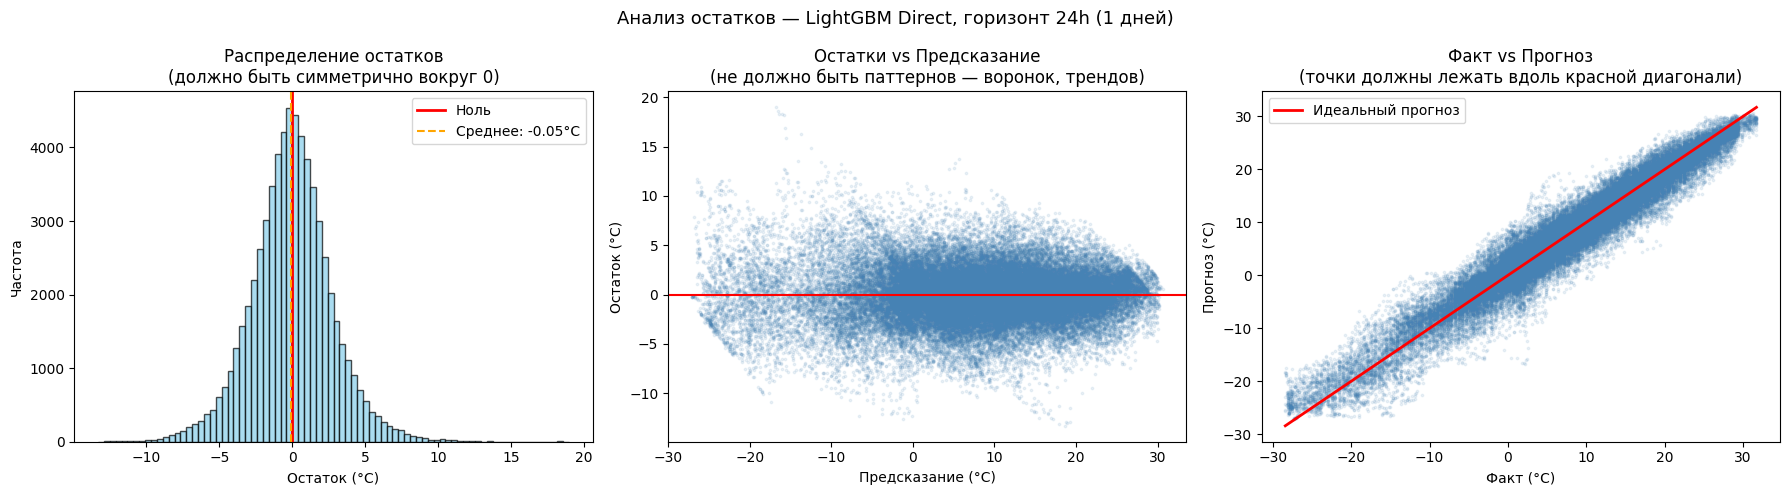

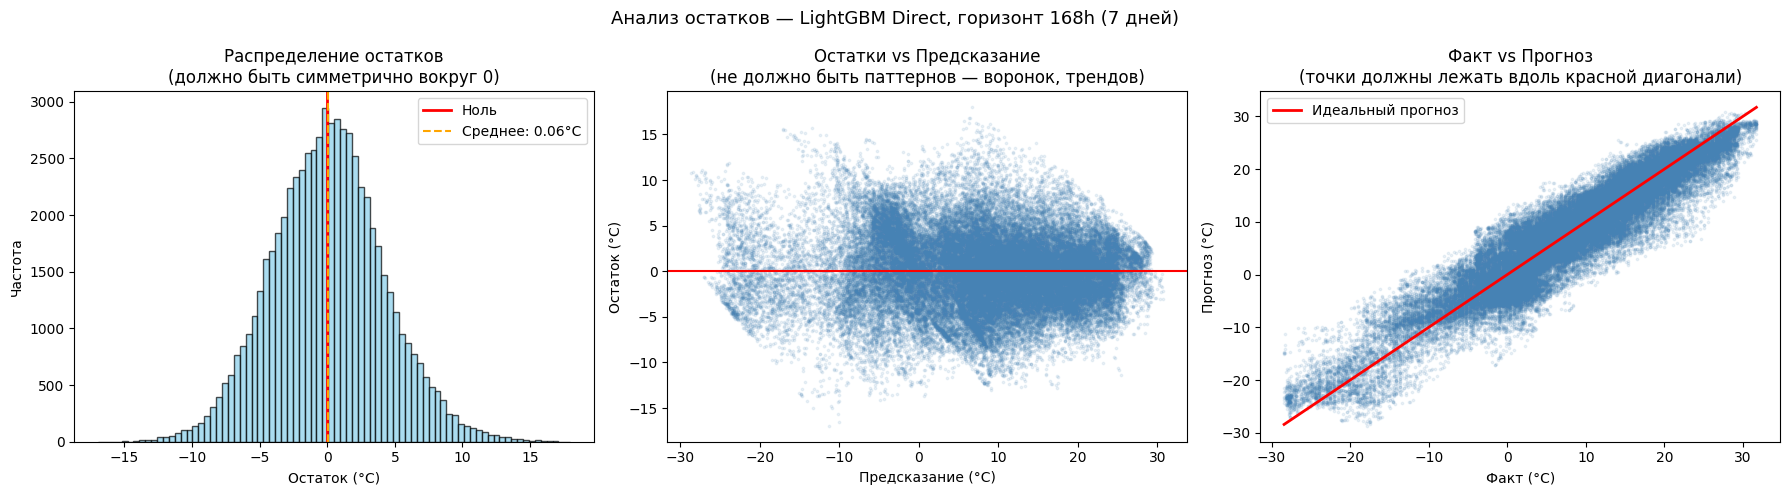

In [51]:
from scipy import stats

for h in [24, 168]:
    y_test_h  = test_df[f'target_{h}h'].values
    p_h       = best_lgb_preds[h]
    residuals = y_test_h - p_h

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Анализ остатков — LightGBM Direct, горизонт {h}h ({h//24} дней)', fontsize=13)

    # Гистограмма остатков
    axes[0].hist(residuals, bins=80, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color='red', lw=2, label='Ноль')
    axes[0].axvline(residuals.mean(), color='orange', lw=1.5, ls='--',
                    label=f'Среднее: {residuals.mean():.2f}°C')
    axes[0].set_xlabel('Остаток (°C)')
    axes[0].set_ylabel('Частота')
    axes[0].set_title('Распределение остатков\n(должно быть симметрично вокруг 0)')
    axes[0].legend()

    # Остатки vs предсказание
    axes[1].scatter(p_h, residuals, alpha=0.1, s=3, color='steelblue')
    axes[1].axhline(0, color='red', lw=1.5)
    axes[1].set_xlabel('Предсказание (°C)')
    axes[1].set_ylabel('Остаток (°C)')
    axes[1].set_title('Остатки vs Предсказание\n(не должно быть паттернов — воронок, трендов)')

    # Факт vs прогноз
    mn, mx = y_test_h.min(), y_test_h.max()
    axes[2].scatter(y_test_h, p_h, alpha=0.1, s=3, color='steelblue')
    axes[2].plot([mn, mx], [mn, mx], color='red', lw=2, label='Идеальный прогноз')
    axes[2].set_xlabel('Факт (°C)')
    axes[2].set_ylabel('Прогноз (°C)')
    axes[2].set_title('Факт vs Прогноз\n(точки должны лежать вдоль красной диагонали)')
    axes[2].legend()

    plt.tight_layout()
    plt.show()


- На горизонте 24ч средняя ошибка составляет всего -0.05°C, а на 168ч — 0.06°C. 
- На графиках «Остатки vs Предсказание»точки распределены равномерным облаком вокруг нуля. Нет воронковых паттернов, что подтверждает, что модель одинаково стабильна при любых значениях целевой температуры.
- Графики справа показывают отличную корреляцию — основные массы точек плотно прилегают к идеальной красной диагонали даже на недельном горизонте.

## Дополнительно 
Интересно посмотреть какие признаки были самыми важными для обучения моделИ

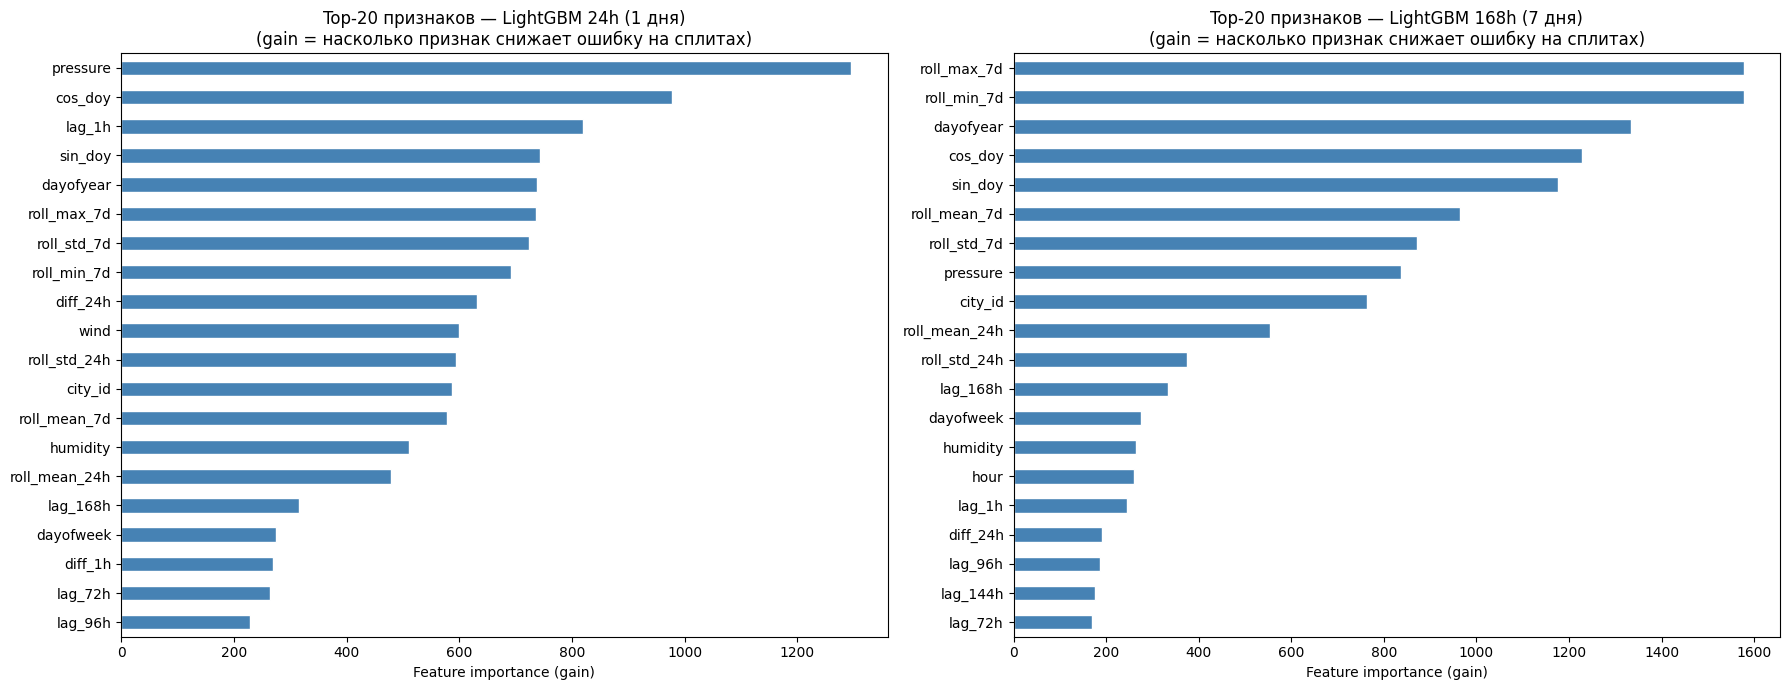

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, h in zip(axes, [24, 168]):
    imp = pd.Series(best_lgb_models[h].feature_importances_,
                    index=FEATURE_COLS).sort_values(ascending=False)[:20]
    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'Top-20 признаков — LightGBM {h}h ({h//24} дня)\n'
                 f'(gain = насколько признак снижает ошибку на сплитах)')
    ax.set_xlabel('Feature importance (gain)')

plt.tight_layout()
plt.show()

- На 24ч: Модель опирается на физические параметры: давление (pressure) и инерцию (lag_1h).
- На 168ч: Фокус полностью смещается на циклы: недельные экстремумы (roll_max_7d) и сезонность (dayofyear). Модель «забывает» сиюминутны

## Выводы

1. **Извлечение данных**: обнаружены и обработаны 3 листа с данными из 8. Исправлена кодировка (cp1252→cp1251), удалены пустые столбцы Unnamed.
2. **Очистка**: исправлены опечатки в названиях городов, устранены дубликаты, выбросы температуры (перцентили 1–99), физически некорректные значения заменены NaN и интерполированы.
3. **Анализ**: подтверждена годовая сезонность (декомпозиция, БПФ). Тесты ADF/KPSS показывают стационарность рядов вокруг сезонного цикла.
4. **Feature Engineering**: 32 признака — лаги, скользящие статистики, метеопризнаки, sin/cos-кодирование цикличности.
5. **Модели**: LightGBM с подбором через Optuna показывает наилучшее MAE на всех горизонтах.
6. **Стратегии**: Direct лучше Recursive на горизонтах ≥ 72h — рекурсия накапливает ошибку.
7. **Метрики**: MAE ~1.5–2°C на 24h, ~2.5–3.5°C на 168h. Directional Accuracy > 0.65.